In [2]:
import pandas as pd
import umap
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import numpy as np

In [3]:
def preprocess_and_umap(adata):
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

In [4]:
PANCREAS = "/local/home/ktubis/PycharmProjects/scGPT/delta_tuning/data/scRNAseq_Benchmark_datasets/Intra-dataset/Pancreatic_data/"
DATASETS = ["Baron_Human", "Muraro", "Segerstolpe", "Xin"]
DATA_FILE = "/Filtered_data.csv"
LABELS_FILE = "/Labels.csv"

In [5]:
datasets = {}
labels = {}
for dataset in DATASETS:
    datasets[dataset] = pd.read_csv(PANCREAS + dataset + DATA_FILE)
    datasets[dataset].set_index("Unnamed: 0", inplace=True)
    labels[dataset] = pd.read_csv(PANCREAS + dataset + LABELS_FILE)

In [11]:
muraro_genes = [gene.split("__")[0] for gene in datasets["Muraro"].columns]
datasets["Muraro"].columns = muraro_genes

In [12]:
for dataset in datasets:
    print(dataset, datasets[dataset].shape)
    print(set(labels[dataset]["x"]))

Baron_Human (8569, 17499)
{'mast', 'gamma', 'delta', 'ductal', 'activated_stellate', 'schwann', 't_cell', 'acinar', 'alpha', 'quiescent_stellate', 'endothelial', 'macrophage', 'beta', 'epsilon'}
Muraro (2122, 18915)
{'mesenchymal', 'delta', 'duct', 'acinar', 'alpha', 'endothelial', 'beta', 'pp', 'epsilon'}
Segerstolpe (2133, 22757)
{'MHC class II', 'mast', 'gamma', 'delta', 'ductal', 'unclassified endocrine', 'acinar', 'alpha', 'co-expression', 'endothelial', 'PSC', 'beta', 'epsilon'}
Xin (1449, 33889)
{'beta', 'gamma', 'delta', 'alpha'}


In [13]:
all_labels = set()
for dataset in labels.keys():
    all_labels.update(labels[dataset]["x"])

In [14]:
len(all_labels)

21

In [15]:
genes = set(list(datasets[DATASETS[0]].columns))
for dataset in DATASETS[1:]:
    new_genes_set = set(list(datasets[dataset].columns))
    genes = genes.intersection(new_genes_set)

In [16]:
genes = list(genes)

In [17]:
for dataset in datasets:
    datasets[dataset] = datasets[dataset][genes]

In [18]:
adatas = {}
for dataset in datasets:
    print(dataset)
    adatas[dataset] = ad.AnnData(datasets[dataset])
    X_dense = adatas[dataset].X.A if hasattr(adatas[dataset].X, 'A') else adatas[dataset].X
    adatas[dataset].X = np.array(X_dense, dtype=np.float32)
    adatas[dataset].obs['label'] = list(labels[dataset]['x'])
    adatas[dataset].obs['dataset'] = dataset
    duplicates = adatas[dataset].var_names.duplicated(keep='first')
    adatas[dataset] = adatas[dataset][:, ~duplicates].copy()

Baron_Human
Muraro


/local/home/ktubis/anaconda3/envs/scGPT/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Segerstolpe
Xin


/local/home/ktubis/anaconda3/envs/scGPT/lib/python3.12/site-packages/anndata/utils.py:307: UserWarning: X converted to numpy array with dtype float64
  warnings.warn(f"{name} converted to numpy array with dtype {arr.dtype}")


In [19]:
indices = np.random.choice(adatas["Baron_Human"].n_obs, size=2000, replace=False)
adatas["Baron_Subsampled"] = adatas["Baron_Human"][indices].copy()

In [20]:
combined = ad.concat(
    [adatas["Baron_Subsampled"], adatas["Muraro"], adatas["Xin"]],
    label="ds_on_concat",
    keys=["Baron_Subsampled", "Muraro", "Xin"],
    index_unique="-",
    axis=0,
)

# Regular Normalization + UMAP

In [ ]:
for dataset in adatas:
    preprocess_and_umap(adatas[dataset])

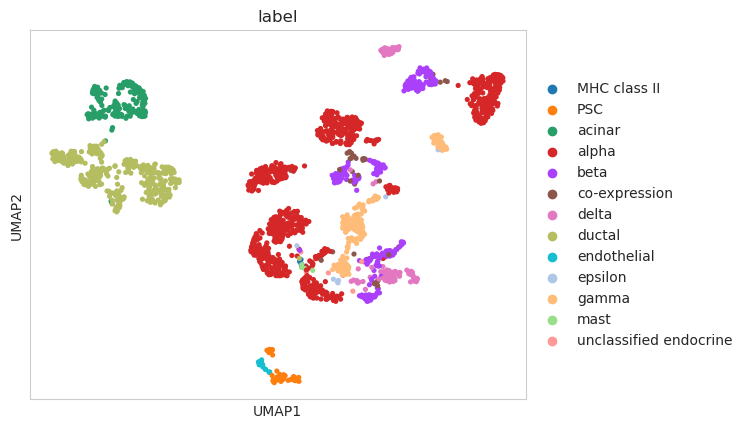

In [47]:
sc.pl.umap(adatas["Segerstolpe"], color='label')

In [48]:
sc.pp.pca(combined, n_comps=2)
sc.pp.neighbors(combined)
sc.tl.umap(combined)

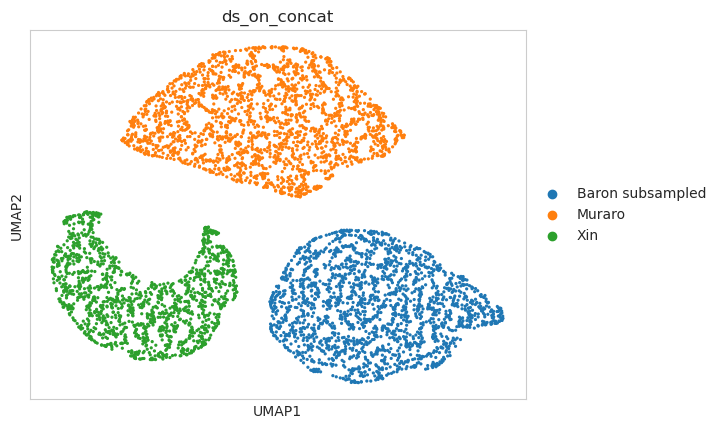

In [49]:
sc.pl.umap(combined, color='ds_on_concat')

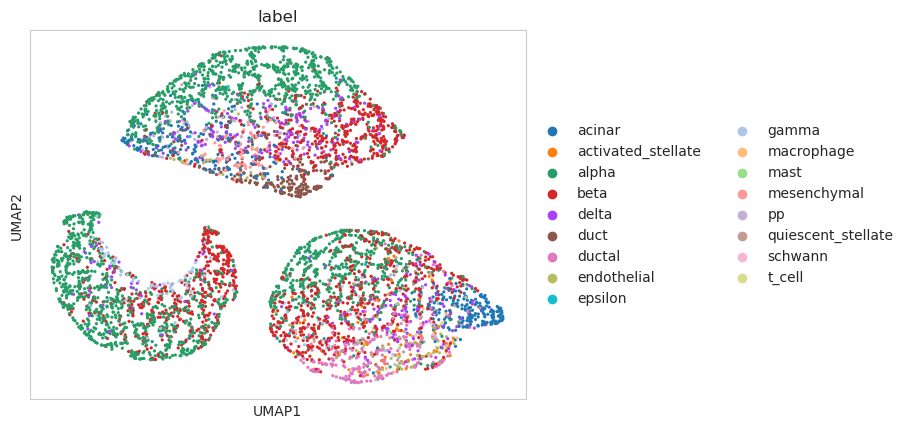

In [50]:
sc.pl.umap(combined, color='label')

# Binning the gene values

In [66]:
n_bins=51

In [120]:
scgpt_preprocessor = Preprocessor(use_key="X",  # the key in adata.layers to use as raw data
    filter_gene_by_counts=False,  # step 1
    filter_cell_by_counts=False,  # step 2
    normalize_total=False,  # 3. whether to normalize the raw data and to what sum
    result_normed_key="X_normed",  # the key in adata.layers to store the normalized data
    log1p=False,  # 4. whether to log1p the normalized data
    result_log1p_key="X_log1p",
    binning=n_bins,  # 6. whether to bin the raw data and to what number of bins
    result_binned_key="X_binned",  # the key in adata.layers to store the binned data)
)

In [124]:
scgpt_preprocessor(combined, batch_key='ds_on_concat')

scGPT - INFO - Binning data ...


In [127]:
sc.pp.pca(combined, layer="X_binned")
sc.pp.neighbors(combined)
sc.tl.umap(combined)

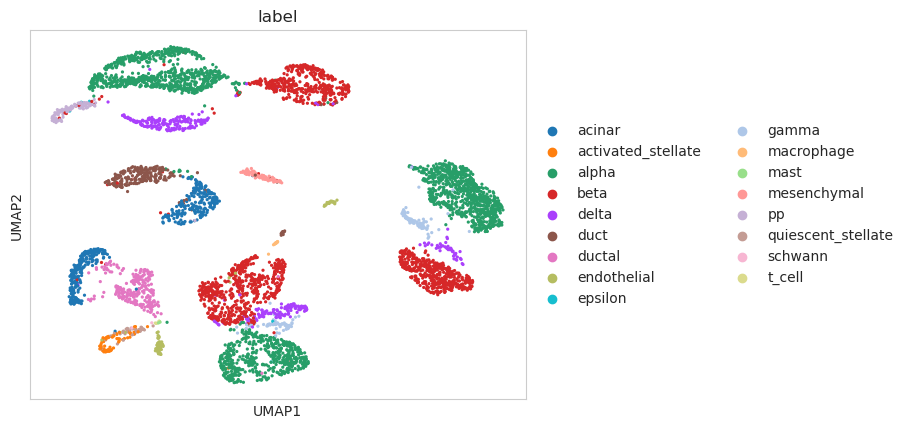

In [129]:
sc.pl.umap(combined, color='label')

In [149]:
row = adatas["Segerstolpe"].X[20]
non_zero_ids = row.nonzero()
non_zero_row = row[non_zero_ids]

In [156]:
sum(non_zero_row == 3)

np.int64(54)

In [155]:
len(non_zero_row)

5178

In [134]:
np.histogram(non_zero_row, bins="auto")

(array([872, 434, 394, ...,   0,   0,   1]),
 array([1.0000000e+00, 1.4505156e+01, 2.8010311e+01, ..., 1.3225698e+05,
        1.3227050e+05, 1.3228400e+05], dtype=float32))

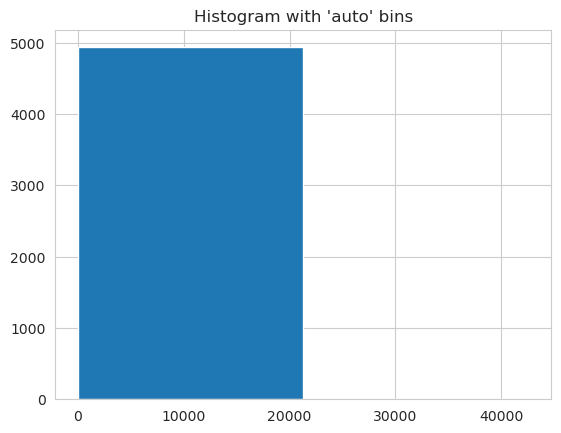

In [147]:
plt.hist(a, bins=2)  # arguments are passed to np.histogram
plt.title("Histogram with 'auto' bins")
plt.show()


In [146]:
a = sorted(non_zero_row)[:-1]

In [148]:
a[-20:]

[np.float32(1594.0),
 np.float32(1612.0),
 np.float32(1692.0),
 np.float32(1724.0),
 np.float32(1740.0),
 np.float32(1810.0),
 np.float32(2070.0),
 np.float32(2091.0),
 np.float32(2156.0),
 np.float32(2334.0),
 np.float32(2535.0),
 np.float32(2922.0),
 np.float32(3781.0),
 np.float32(4811.0),
 np.float32(9387.0),
 np.float32(11835.0),
 np.float32(11923.0),
 np.float32(13301.0),
 np.float32(40587.0),
 np.float32(42583.0)]

In [137]:
print(np.isnan(non_zero_row).sum(), np.isinf(non_zero_row).sum())

0 0


In [164]:
pct_ones = []
for row in combined.X:
    non_zero_ids = row.nonzero()
    non_zero_row = row[non_zero_ids]
    pct_ones.append(sum(non_zero_row == np.min(non_zero_row)) / len(non_zero_row))

In [165]:
sorted(pct_ones)

[np.float64(0.00014330753797649757),
 np.float64(0.00014712373105781962),
 np.float64(0.00014894250819183795),
 np.float64(0.00014949917775452235),
 np.float64(0.0001518141794443601),
 np.float64(0.00015318627450980392),
 np.float64(0.0001537042729787888),
 np.float64(0.00015401201293700908),
 np.float64(0.0001546551190844417),
 np.float64(0.0001546551190844417),
 np.float64(0.0001550387596899225),
 np.float64(0.00015513496742165683),
 np.float64(0.0001554726368159204),
 np.float64(0.00015738117721120554),
 np.float64(0.00015748031496062991),
 np.float64(0.00015842839036755386),
 np.float64(0.0001585037248375337),
 np.float64(0.00015895724050230488),
 np.float64(0.0001590077913817777),
 np.float64(0.0001590836780146357),
 np.float64(0.00016015374759769378),
 np.float64(0.00016015374759769378),
 np.float64(0.00016043638697256537),
 np.float64(0.00016051364365971107),
 np.float64(0.00016108247422680412),
 np.float64(0.00016121231662098983),
 np.float64(0.00016202203499675956),
 np.float6

In [168]:
np.median(pct_ones)

np.float64(0.5058789790650989)

In [49]:
preprocessor = Preprocessor(
    use_key="X",  # the key in adata.layers to use as raw data
    filter_gene_by_counts=3,  # step 1
    filter_cell_by_counts=False,  # step 2
    normalize_total=1e4,  # 3. whether to normalize the raw data and to what sum
    result_normed_key="X_normed",  # the key in adata.layers to store the normalized data
    log1p=True,  # 4. whether to log1p the normalized data
    result_log1p_key="X_log1p",
    subset_hvg=1200,  # 5. whether to subset the raw data to highly variable genes
    hvg_flavor="cell_ranger",
    binning=51,  # 6. whether to bin the raw data and to what number of bins
    result_binned_key="X_binned",  # the key in adata.layers to store the binned data
)

In [58]:
baron_backup = adatas["Baron_Human"].copy()

In [60]:
adata_baron = adatas["Baron_Human"].copy()

In [52]:
preprocessor(baron_backup)

scGPT - INFO - Filtering genes by counts ...
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Subsetting highly variable genes ...
scGPT - WARNING - No batch_key is provided, will use all cells for HVG selection.
scGPT - INFO - Binning data ...


In [53]:
baron_backup.layers["X_binned"]

array([[ 0,  0, 47, ...,  0,  0,  0],
       [ 0,  0, 48, ...,  0,  2,  0],
       [ 0,  0, 47, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0, 49, ...,  0,  0,  0]])

In [54]:
preprocessor2 = Preprocessor(
    use_key="X",  # the key in adata.layers to use as raw data
    filter_gene_by_counts=3,  # step 1
    filter_cell_by_counts=False,  # step 2
    normalize_total=1e4,  # 3. whether to normalize the raw data and to what sum
    result_normed_key="X_normed",  # the key in adata.layers to store the normalized data
    log1p=True,  # 4. whether to log1p the normalized data
    result_log1p_key="X_log1p",
    subset_hvg=1200,  # 5. whether to subset the raw data to highly variable genes
    hvg_flavor="cell_ranger",
    binning=51,  # 6. whether to bin the raw data and to what number of bins
    result_binned_key="X_binned",  # the key in adata.layers to store the binned data
    hvg_use_key="X_log1p",
)

In [55]:
preprocessor2(adata_baron)

scGPT - INFO - Filtering genes by counts ...
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Subsetting highly variable genes ...
scGPT - WARNING - No batch_key is provided, will use all cells for HVG selection.
scGPT - INFO - Binning data ...


In [57]:
adata_baron.layers["X_binned"]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [59]:
preprocessor2(baron_backup)
baron_backup.layers["X_binned"]

scGPT - INFO - Filtering genes by counts ...
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Subsetting highly variable genes ...
scGPT - WARNING - No batch_key is provided, will use all cells for HVG selection.
scGPT - INFO - Binning data ...


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [61]:
preprocessor(adata_baron)

scGPT - INFO - Filtering genes by counts ...
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Subsetting highly variable genes ...
scGPT - WARNING - No batch_key is provided, will use all cells for HVG selection.
scGPT - INFO - Binning data ...


In [62]:
adata_baron.layers["X_binned"]

array([[ 0,  0, 47, ...,  0,  0,  0],
       [ 0,  0, 48, ...,  0,  9,  0],
       [ 0,  0, 47, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0, 49, ...,  0,  0,  0]])

In [2]:
import load_ds

In [3]:
data_loader = load_ds.PancreaticDataset()

In [4]:
adata, id2type = data_loader.load_all_datasets()

KeyError: "None of ['Unnamed: 0'] are in the columns"